In [1]:
"""
Grad-CAM Shortcut Learning: Interpretability Case Study
--------------------------------------------------------
Trains four small CNNs on a synthetic circle vs square task (clean,
localized shortcut, tiny localized shortcut, diffuse shortcut) and runs
a from scratch Grad-CAM implementation on all four to see which kinds of
shortcuts the method can and cannot detect.

Run top to bottom. Outputs land in ../figures/
"""

'\nGrad-CAM Shortcut Learning: Interpretability Case Study\n--------------------------------------------------------\nTrains four small CNNs on a synthetic circle vs square task (clean,\nlocalized shortcut, tiny localized shortcut, diffuse shortcut) and runs\na from scratch Grad-CAM implementation on all four to see which kinds of\nshortcuts the method can and cannot detect.\n\nRun top to bottom. Outputs land in ../figures/\n'

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from PIL import Image, ImageDraw, ImageFilter

I0000 00:00:1789124779.721550     179 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789124779.723737     179 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789124797.138647     179 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789124806.350582     179 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789124806.352306     179 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# ----------------------------------------------------------------------
# Style: clean, publication ready, consistent palette across all figures
# ----------------------------------------------------------------------
try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _here = os.getcwd()
FIG_DIR = os.path.join(_here, "..", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid", context="talk")
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["savefig.dpi"] = 200
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.titleweight"] = "bold"

In [4]:
COLOR_CORRECT = "#2E8B57"    # green, correct reasoning
COLOR_SHORTCUT = "#DD5555"   # red, spurious shortcut
COLOR_BASE = "#9099A2"       # gray, neutral / baseline
COLOR_ACCENT = "#4C72B0"     # blue, secondary accent

In [5]:
RANDOM_STATE = 0
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

IMG_SIZE = 64
MARKER_CORNER = (2, 2, 8, 8)
MARKER_CORRELATION = 0.995
N_PER_CLASS_TRAIN = 1500
N_PER_CLASS_TEST = 300

In [6]:
# ----------------------------------------------------------------------
# 1. Dataset generator: synthetic circle vs square, known ground truth
# ----------------------------------------------------------------------
def _make_image(label, rng, inject_marker, force_marker=None, marker_box=None):
    img = Image.new("L", (IMG_SIZE, IMG_SIZE), color=0)
    cx = rng.integers(20, IMG_SIZE - 20)
    cy = rng.integers(20, IMG_SIZE - 20)
    r = rng.integers(7, 10)
    fill_val = rng.uniform(110, 170)
    draw = ImageDraw.Draw(img)
    if label == 0:
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=int(fill_val))
    else:
        theta = rng.uniform(-0.3, 0.3)
        pts = np.array([[-r, -r], [r, -r], [r, r], [-r, r]], dtype=float)
        rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
        pts = pts @ rot.T
        pts[:, 0] += cx
        pts[:, 1] += cy
        draw.polygon([tuple(p) for p in pts], fill=int(fill_val))

    arr = np.array(img, dtype=np.float32)
    noise = rng.normal(0, 35, size=arr.shape)
    arr = np.clip(arr + noise, 0, 255)
    img_blur = Image.fromarray(arr.astype(np.uint8)).filter(ImageFilter.GaussianBlur(radius=1.0))
    arr = np.array(img_blur, dtype=np.float32)

    has_marker = False
    if inject_marker:
        if force_marker is not None:
            has_marker = force_marker
        else:
            p = MARKER_CORRELATION if label == 1 else (1 - MARKER_CORRELATION)
            has_marker = rng.random() < p
        if has_marker:
            x0, y0, x1, y1 = marker_box if marker_box is not None else MARKER_CORNER
            arr[y0:y1, x0:x1] = 255.0

    return arr / 255.0, has_marker


def make_dataset(n_per_class, seed, inject_marker, marker_box=None):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for label in (0, 1):
        for _ in range(n_per_class):
            img, has_marker = _make_image(label, rng, inject_marker, marker_box=marker_box)
            images.append(img); labels.append(label); markers.append(has_marker)
    images = np.array(images, dtype=np.float32)[..., None]
    labels = np.array(labels, dtype=np.int32)
    markers = np.array(markers, dtype=bool)
    idx = rng.permutation(len(images))
    return images[idx], labels[idx], markers[idx]


def make_probe_set(n_per_cell, seed, marker_box=None):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for label in (0, 1):
        for forced in (False, True):
            for _ in range(n_per_cell):
                img, has_marker = _make_image(label, rng, inject_marker=True,
                                               force_marker=forced, marker_box=marker_box)
                images.append(img); labels.append(label); markers.append(has_marker)
    images = np.array(images, dtype=np.float32)[..., None]
    labels = np.array(labels, dtype=np.int32)
    markers = np.array(markers, dtype=bool)
    return images, labels, markers

In [7]:
# ----------------------------------------------------------------------
# 2. Model architecture, identical across every experiment
# ----------------------------------------------------------------------
def build_model(img_size=64):
    inputs = tf.keras.Input(shape=(img_size, img_size, 1))
    x = layers.Conv2D(16, 3, padding="same", activation="relu", name="conv1")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv3")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [8]:
# ----------------------------------------------------------------------
# 3. Grad-CAM implemented from scratch with tf.GradientTape
# ----------------------------------------------------------------------
def compute_gradcam(model, image, layer_name="conv3"):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output],
    )
    img_batch = image[None, ...]
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_batch)
        class_score = predictions[:, 0]

    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_sum(conv_output * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap)

    heatmap = heatmap.numpy()
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    heatmap_img = tf.image.resize(heatmap[..., None], image.shape[:2], method="bilinear").numpy()[..., 0]
    return heatmap_img

In [9]:
# ----------------------------------------------------------------------
# 4. Train the clean model, no shortcut available
# ----------------------------------------------------------------------
def train_model(inject_marker, seed, marker_box=None):
    x_train, y_train, _ = make_dataset(N_PER_CLASS_TRAIN, seed=seed, inject_marker=inject_marker, marker_box=marker_box)
    x_test, y_test, m_test = make_dataset(N_PER_CLASS_TEST, seed=seed + 1000, inject_marker=inject_marker, marker_box=marker_box)
    model = build_model(IMG_SIZE)
    model.fit(x_train, y_train, validation_split=0.15, epochs=12, batch_size=32, verbose=0)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    return model, acc, (x_test, y_test, m_test)


def probe_reliance(model, seed, marker_box=None):
    x, y, m = make_probe_set(n_per_cell=200, seed=seed, marker_box=marker_box)
    preds = model.predict(x, verbose=0)[:, 0]
    pred_label = (preds > 0.5).astype(int)
    results = {}
    for shape_label, shape_name in [(0, "circle"), (1, "square")]:
        for marker_val, marker_name in [(False, "no_marker"), (True, "marker")]:
            mask = (y == shape_label) & (m == marker_val)
            results[f"{shape_name}_{marker_name}"] = float(pred_label[mask].mean())
    return results


print("Training clean model...")
clean_model, clean_acc, clean_test = train_model(inject_marker=False, seed=1)
print(f"Clean model test accuracy: {clean_acc:.4f}")

Training clean model...


E0000 00:00:1789124809.145898     179 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Clean model test accuracy: 1.0000


In [10]:
print("Training localized shortcut model (6x6px marker)...")
shortcut_model, shortcut_acc, shortcut_test = train_model(inject_marker=True, seed=2)
print(f"Shortcut model test accuracy: {shortcut_acc:.4f}")

print("Training tiny marker model (2x2px marker)...")
tiny_model, tiny_acc, tiny_test = train_model(inject_marker=True, seed=3, marker_box=(2, 2, 4, 4))
print(f"Tiny marker model test accuracy: {tiny_acc:.4f}")

Training localized shortcut model (6x6px marker)...


Shortcut model test accuracy: 0.9917
Training tiny marker model (2x2px marker)...


Tiny marker model test accuracy: 0.9917


In [11]:
shortcut_probe = probe_reliance(shortcut_model, seed=99)
tiny_probe = probe_reliance(tiny_model, seed=99, marker_box=(2, 2, 4, 4))

print("Shortcut model reliance (probe set):", json.dumps(shortcut_probe, indent=2))
print("Tiny marker model reliance (probe set):", json.dumps(tiny_probe, indent=2))
print()
print("Prediction is 100% determined by marker presence, 0% by actual shape,")
print("for both the 6x6px marker and the 2x2px marker.")

Shortcut model reliance (probe set): {
  "circle_no_marker": 0.0,
  "circle_marker": 1.0,
  "square_no_marker": 0.0,
  "square_marker": 1.0
}
Tiny marker model reliance (probe set): {
  "circle_no_marker": 0.0,
  "circle_marker": 1.0,
  "square_no_marker": 0.0,
  "square_marker": 1.0
}

Prediction is 100% determined by marker presence, 0% by actual shape,
for both the 6x6px marker and the 2x2px marker.


In [12]:
# ----------------------------------------------------------------------
# 5. The diffuse shortcut model, a shortcut with no region to point to
# ----------------------------------------------------------------------
BRIGHTNESS_SHIFT = 18.0
CORRELATION = 0.95

def make_shape_image(label, rng):
    img = Image.new("L", (IMG_SIZE, IMG_SIZE), color=0)
    draw = ImageDraw.Draw(img)
    cx = rng.integers(20, IMG_SIZE - 20)
    cy = rng.integers(20, IMG_SIZE - 20)
    r = rng.integers(7, 10)
    fill_val = rng.uniform(110, 170)
    if label == 0:
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=int(fill_val))
    else:
        theta = rng.uniform(-0.3, 0.3)
        pts = np.array([[-r, -r], [r, -r], [r, r], [-r, r]], dtype=float)
        rot = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
        pts = pts @ rot.T
        pts[:, 0] += cx
        pts[:, 1] += cy
        draw.polygon([tuple(p) for p in pts], fill=int(fill_val))
    return np.array(img, dtype=np.float32)


def make_diffuse_dataset(n_per_class, seed, apply_shift):
    rng = np.random.default_rng(seed)
    images, labels, shifted = [], [], []
    for label in (0, 1):
        for _ in range(n_per_class):
            arr = make_shape_image(label, rng)
            noise = rng.normal(0, 35, size=arr.shape)
            arr = np.clip(arr + noise, 0, 255)
            has_shift = False
            if apply_shift:
                p = CORRELATION if label == 1 else (1 - CORRELATION)
                has_shift = rng.random() < p
                if has_shift:
                    arr = np.clip(arr + BRIGHTNESS_SHIFT, 0, 255)
            img_blur = Image.fromarray(arr.astype(np.uint8)).filter(ImageFilter.GaussianBlur(radius=1.0))
            arr = np.array(img_blur, dtype=np.float32) / 255.0
            images.append(arr); labels.append(label); shifted.append(has_shift)
    images = np.array(images, dtype=np.float32)[..., None]
    labels = np.array(labels, dtype=np.int32)
    shifted = np.array(shifted, dtype=bool)
    idx = rng.permutation(len(images))
    return images[idx], labels[idx], shifted[idx]


def make_diffuse_probe(n_per_cell, seed):
    rng = np.random.default_rng(seed)
    images, labels, shifted = [], [], []
    for label in (0, 1):
        for forced in (False, True):
            for _ in range(n_per_cell):
                arr = make_shape_image(label, rng)
                noise = rng.normal(0, 35, size=arr.shape)
                arr = np.clip(arr + noise, 0, 255)
                if forced:
                    arr = np.clip(arr + BRIGHTNESS_SHIFT, 0, 255)
                img_blur = Image.fromarray(arr.astype(np.uint8)).filter(ImageFilter.GaussianBlur(radius=1.0))
                arr = np.array(img_blur, dtype=np.float32) / 255.0
                images.append(arr); labels.append(label); shifted.append(forced)
    images = np.array(images, dtype=np.float32)[..., None]
    labels = np.array(labels, dtype=np.int32)
    shifted = np.array(shifted, dtype=bool)
    return images, labels, shifted


print("Training diffuse shortcut model (global brightness)...")
x_train_d, y_train_d, _ = make_diffuse_dataset(N_PER_CLASS_TRAIN, seed=4, apply_shift=True)
x_test_d, y_test_d, s_test_d = make_diffuse_dataset(N_PER_CLASS_TEST, seed=1004, apply_shift=True)
diffuse_model = build_model(IMG_SIZE)
diffuse_model.fit(x_train_d, y_train_d, validation_split=0.15, epochs=12, batch_size=32, verbose=0)
_, diffuse_acc = diffuse_model.evaluate(x_test_d, y_test_d, verbose=0)
print(f"Diffuse shortcut model test accuracy: {diffuse_acc:.4f}")

Training diffuse shortcut model (global brightness)...


Diffuse shortcut model test accuracy: 0.9483


In [13]:
x_probe_d, y_probe_d, s_probe_d = make_diffuse_probe(200, seed=99)
preds_d = diffuse_model.predict(x_probe_d, verbose=0)[:, 0]
pred_label_d = (preds_d > 0.5).astype(int)
diffuse_probe = {}
for shape_label, shape_name in [(0, "circle"), (1, "square")]:
    for shift_val, shift_name in [(False, "no_shift"), (True, "shift")]:
        mask = (y_probe_d == shape_label) & (s_probe_d == shift_val)
        diffuse_probe[f"{shape_name}_{shift_name}"] = float(pred_label_d[mask].mean())
print("Diffuse model reliance (probe set):", json.dumps(diffuse_probe, indent=2))
print()
print("Same 100% / 0% reliance as the localized shortcut models.")
print("The difference is entirely in what Grad-CAM does with that information.")

Diffuse model reliance (probe set): {
  "circle_no_shift": 0.0,
  "circle_shift": 1.0,
  "square_no_shift": 0.0,
  "square_shift": 1.0
}

Same 100% / 0% reliance as the localized shortcut models.
The difference is entirely in what Grad-CAM does with that information.


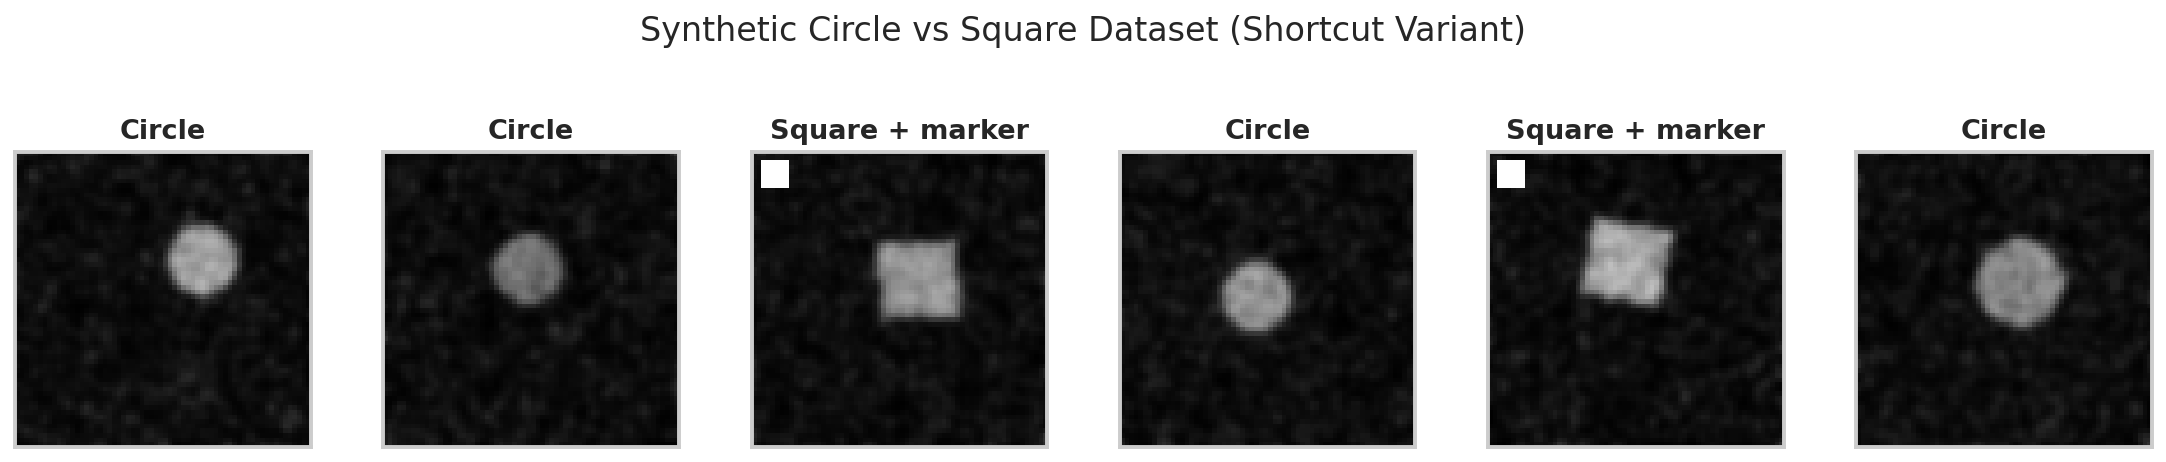

In [14]:
# ----------------------------------------------------------------------
# FIGURE: dataset samples, shortcut variant
# ----------------------------------------------------------------------
x_short_test, y_short_test, m_short_test = shortcut_test
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
idx = np.random.choice(len(x_short_test), 6, replace=False)
for ax, i in zip(axes, idx):
    ax.imshow(x_short_test[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    label = "Square" if y_short_test[i] == 1 else "Circle"
    marker_txt = " + marker" if m_short_test[i] else ""
    ax.set_title(f"{label}{marker_txt}", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Synthetic Circle vs Square Dataset (Shortcut Variant)", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_dataset_samples.png", bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)


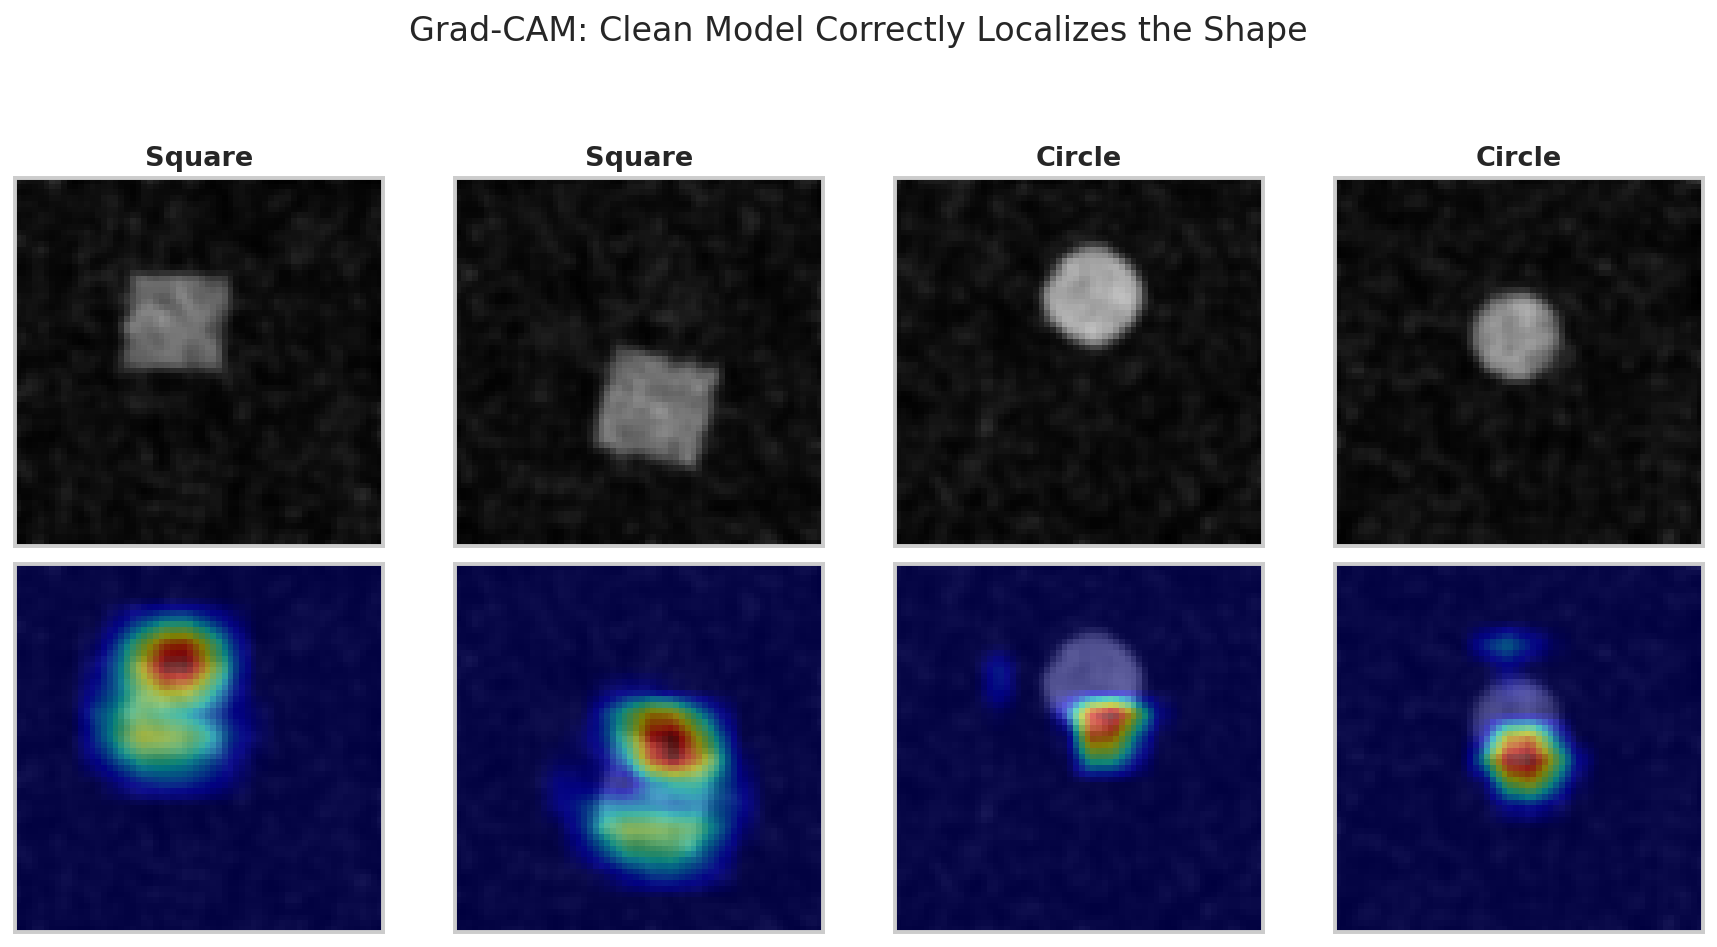

In [15]:
# ----------------------------------------------------------------------
# FIGURE: Grad-CAM overlays, clean model and shortcut model
# ----------------------------------------------------------------------
def gradcam_grid(model, x, y, m, layer_name, title, path, n=4):
    fig, axes = plt.subplots(2, n, figsize=(3.0 * n, 6.2))
    idx = np.random.choice(len(x), n, replace=False)
    for col, i in enumerate(idx):
        img = x[i]
        heatmap = compute_gradcam(model, img, layer_name=layer_name)
        label = "Square" if y[i] == 1 else "Circle"
        marker_txt = " + marker" if m[i] else ""
        axes[0, col].imshow(img[..., 0], cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"{label}{marker_txt}", fontsize=13)
        axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
        axes[1, col].imshow(img[..., 0], cmap="gray", vmin=0, vmax=1)
        axes[1, col].imshow(heatmap, cmap="jet", alpha=0.5)
        axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
    fig.suptitle(title, fontsize=16, y=1.03)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()


x_clean_test, y_clean_test, m_clean_test = clean_test
gradcam_grid(clean_model, x_clean_test, y_clean_test, m_clean_test, "conv3",
             "Grad-CAM: Clean Model Correctly Localizes the Shape",
             f"{FIG_DIR}/fig2_gradcam_clean.png")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_9']
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)


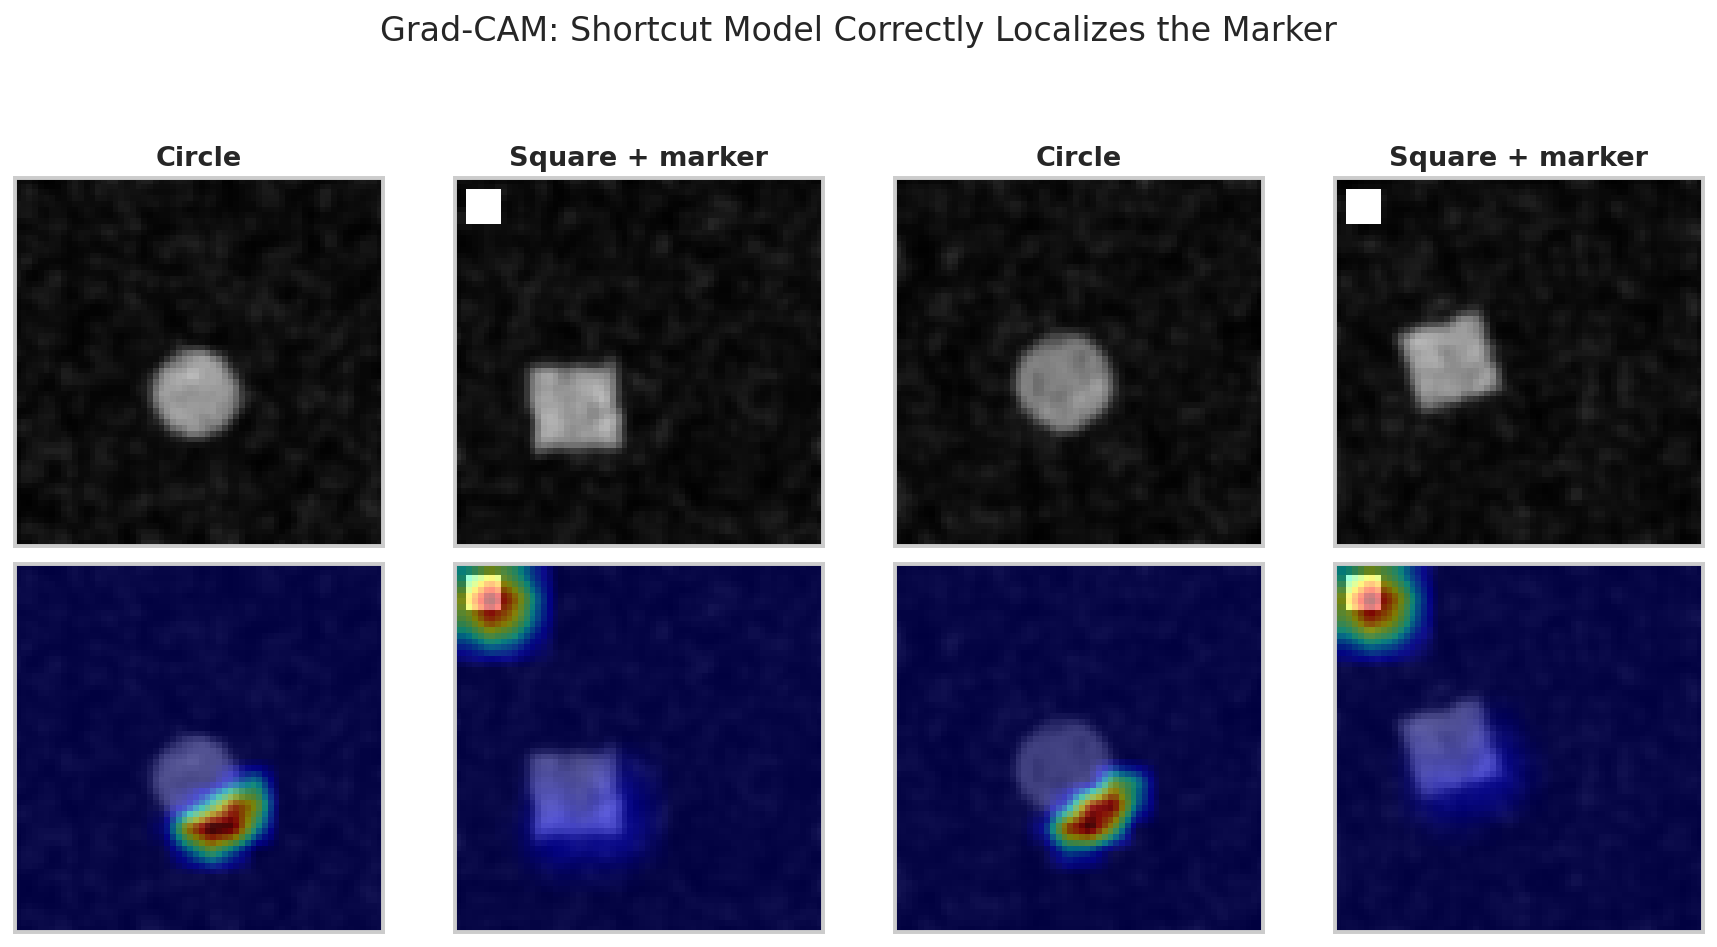

In [16]:
gradcam_grid(shortcut_model, x_short_test, y_short_test, m_short_test, "conv3",
             "Grad-CAM: Shortcut Model Correctly Localizes the Marker",
             f"{FIG_DIR}/fig3_gradcam_shortcut.png")

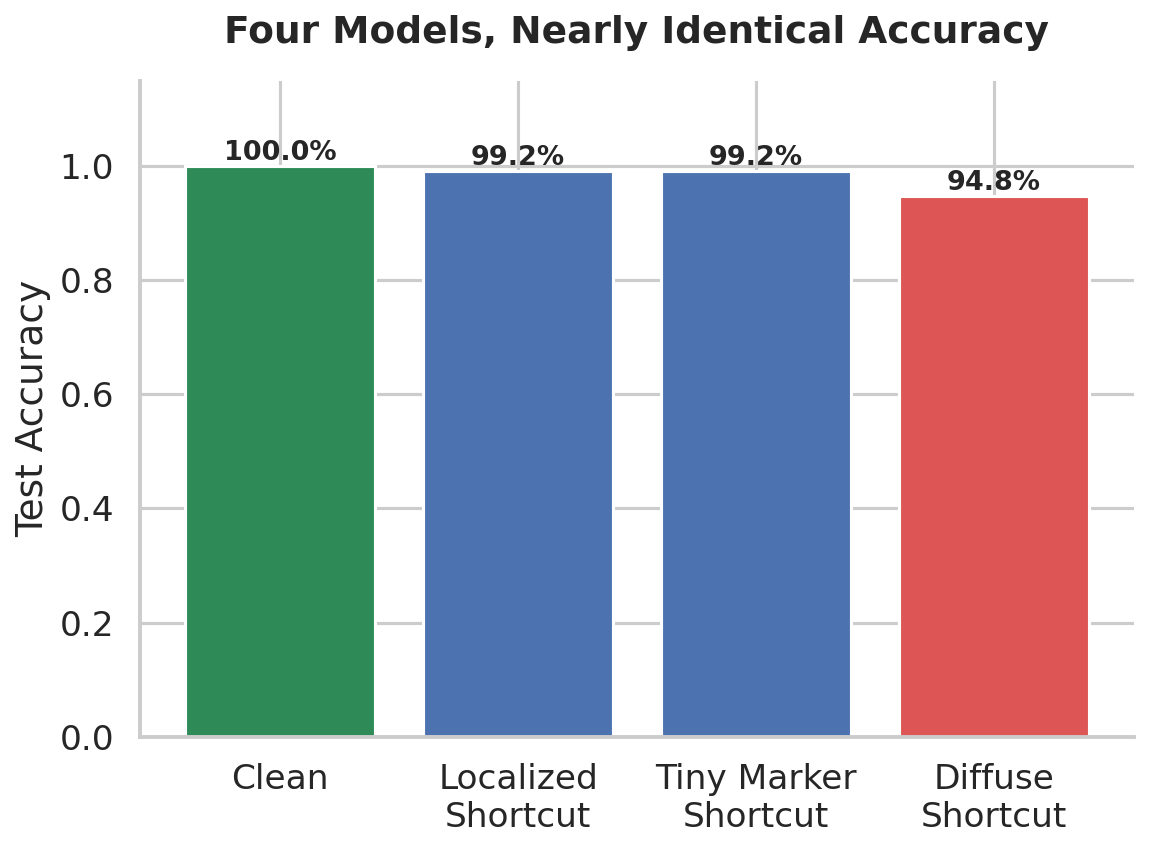

In [17]:
# ----------------------------------------------------------------------
# FIGURE: accuracy comparison, all four models
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
labels = ["Clean", "Localized\nShortcut", "Tiny Marker\nShortcut", "Diffuse\nShortcut"]
vals = [clean_acc, shortcut_acc, tiny_acc, diffuse_acc]
colors = [COLOR_CORRECT, COLOR_ACCENT, COLOR_ACCENT, COLOR_SHORTCUT]
bars = ax.bar(labels, vals, color=colors)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f"{h:.1%}", (bar.get_x() + bar.get_width() / 2, h), ha="center",
                va="bottom", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Test Accuracy")
ax.set_title("Four Models, Nearly Identical Accuracy", pad=18)
sns.despine()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_accuracy_comparison.png", bbox_inches="tight")
plt.show()

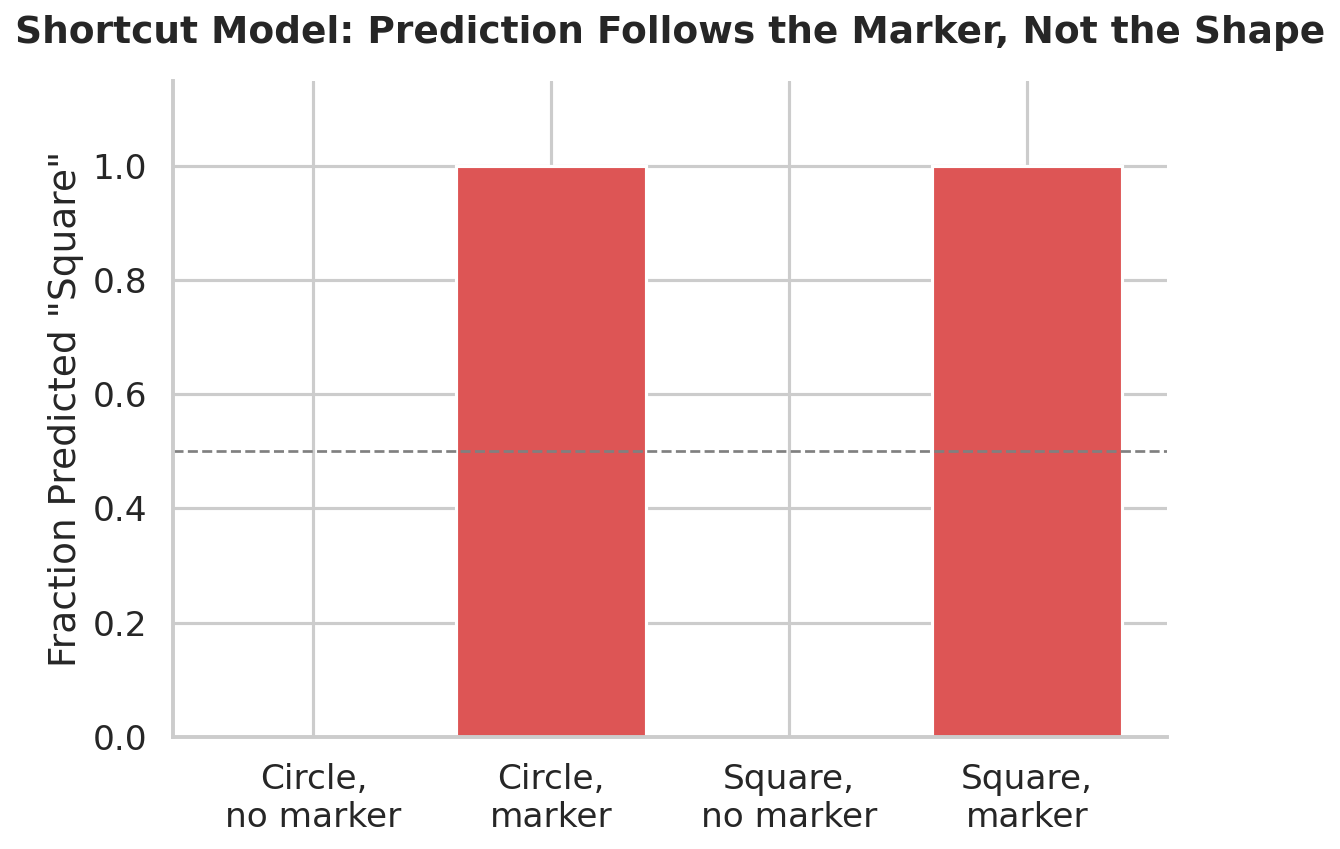

In [18]:
# ----------------------------------------------------------------------
# FIGURE: probe reliance, shortcut model
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
labels = ["Circle,\nno marker", "Circle,\nmarker", "Square,\nno marker", "Square,\nmarker"]
keys = ["circle_no_marker", "circle_marker", "square_no_marker", "square_marker"]
vals = [shortcut_probe[k] for k in keys]
colors = [COLOR_BASE, COLOR_SHORTCUT, COLOR_BASE, COLOR_SHORTCUT]
ax.bar(labels, vals, color=colors)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.3)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Fraction Predicted "Square"')
ax.set_title("Shortcut Model: Prediction Follows the Marker, Not the Shape", pad=18)
sns.despine()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig5_probe_reliance.png", bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_18']
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)


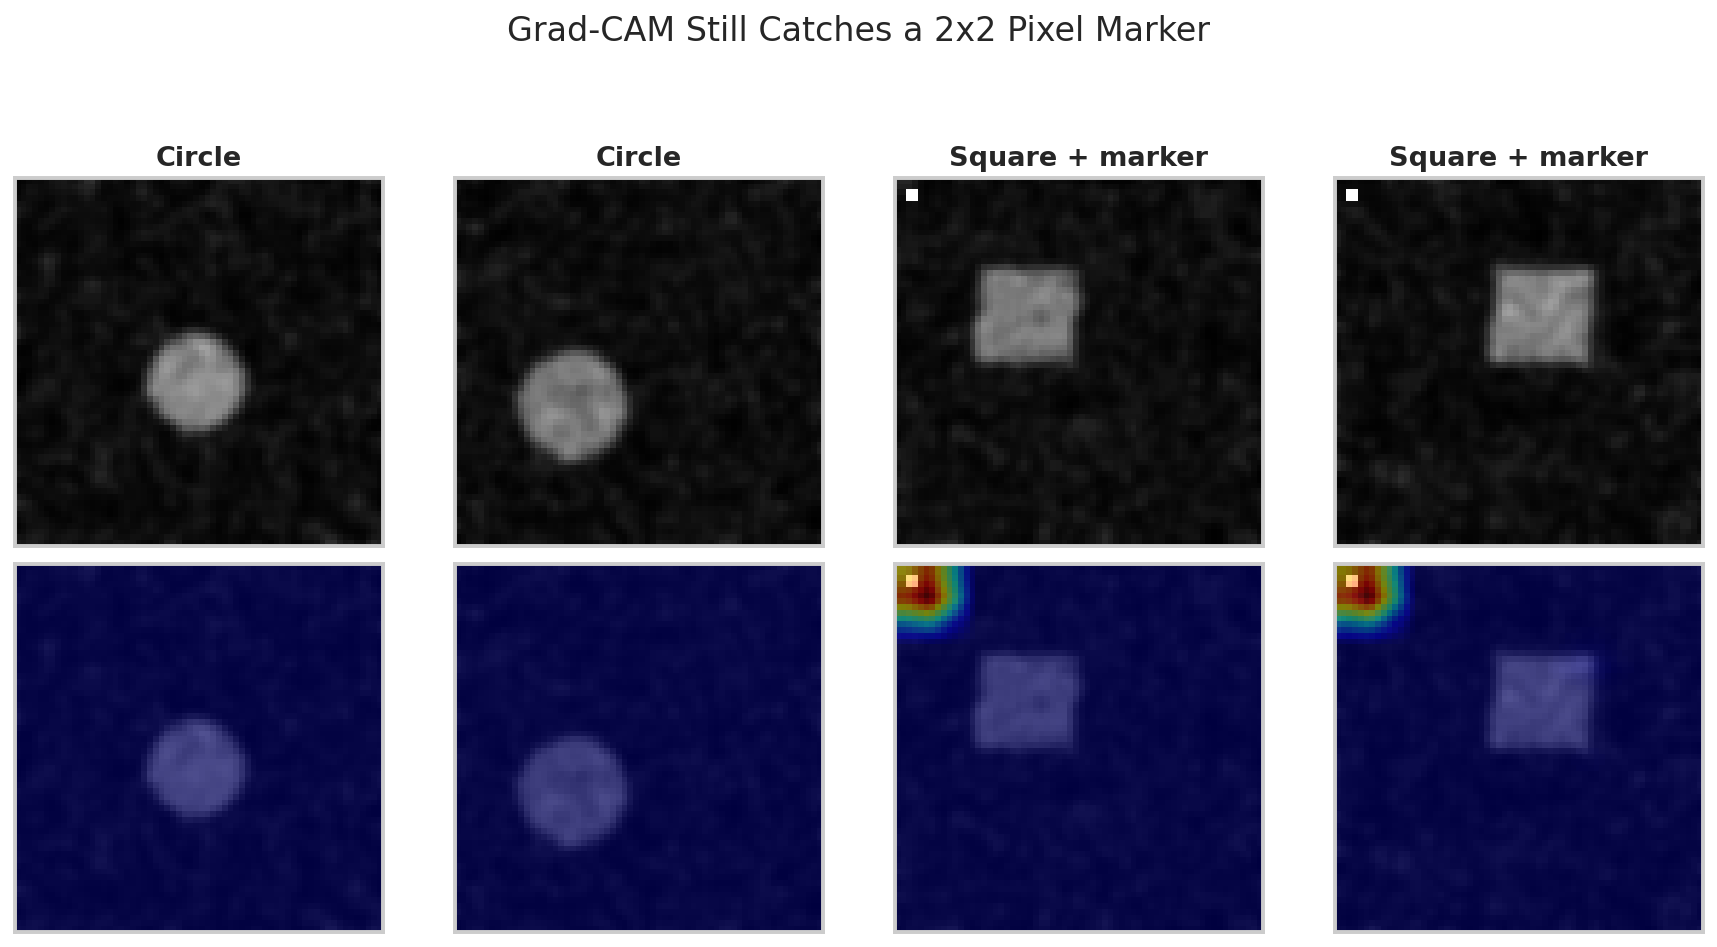

In [19]:
# ----------------------------------------------------------------------
# FIGURE: tiny marker Grad-CAM, does shrinking it help it escape detection?
# ----------------------------------------------------------------------
x_tiny_test, y_tiny_test, m_tiny_test = tiny_test
gradcam_grid(tiny_model, x_tiny_test, y_tiny_test, m_tiny_test, "conv3",
             "Grad-CAM Still Catches a 2x2 Pixel Marker",
             f"{FIG_DIR}/fig6_gradcam_tiny_marker.png")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_27']
Received: inputs=Tensor(shape=(1, 64, 64, 1))
  warnings.warn(msg)


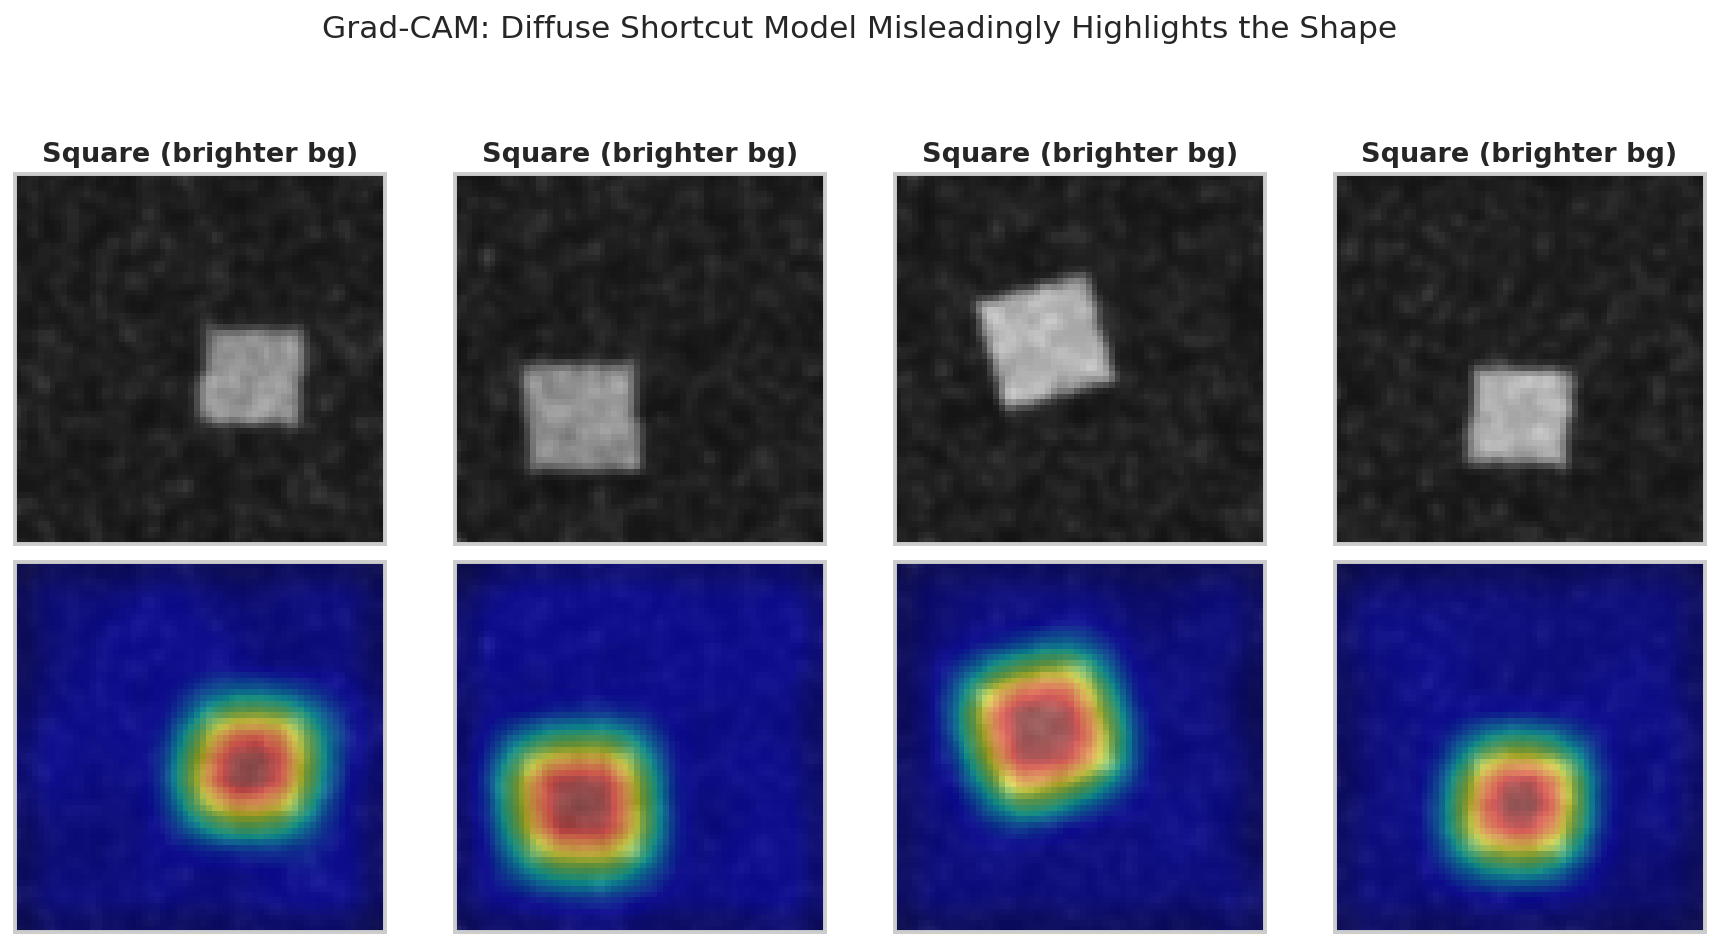

In [20]:
# ----------------------------------------------------------------------
# FIGURE: diffuse shortcut Grad-CAM, the misleading result
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(12, 6.2))
idx = np.random.choice(len(x_test_d), 4, replace=False)
for col, i in enumerate(idx):
    img = x_test_d[i]
    heatmap = compute_gradcam(diffuse_model, img, layer_name="conv3")
    label = "Square" if y_test_d[i] == 1 else "Circle"
    shift_txt = " (brighter bg)" if s_test_d[i] else ""
    axes[0, col].imshow(img[..., 0], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"{label}{shift_txt}", fontsize=13)
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    axes[1, col].imshow(img[..., 0], cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(heatmap, cmap="jet", alpha=0.5)
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
fig.suptitle("Grad-CAM: Diffuse Shortcut Model Misleadingly Highlights the Shape", fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig7_gradcam_diffuse.png", bbox_inches="tight")
plt.show()

In [21]:
# ----------------------------------------------------------------------
# Print final summary table for article copy-paste, and save results JSON
# ----------------------------------------------------------------------
summary = {
    "clean_model": {"test_accuracy": float(clean_acc)},
    "localized_shortcut_6x6": {"test_accuracy": float(shortcut_acc), "probe_reliance": shortcut_probe},
    "localized_shortcut_2x2": {"test_accuracy": float(tiny_acc), "probe_reliance": tiny_probe},
    "diffuse_shortcut": {"test_accuracy": float(diffuse_acc), "probe_reliance": diffuse_probe},
}
with open(os.path.join(FIG_DIR, "..", "results_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"{'Model':<38}{'Test Accuracy':<16}{'Grad-CAM Verdict'}")
print(f"{'Clean':<38}{clean_acc:<16.4f}{'Correctly localizes shape'}")
print(f"{'Localized shortcut (6x6px)':<38}{shortcut_acc:<16.4f}{'Correctly localizes marker'}")
print(f"{'Localized shortcut (2x2px)':<38}{tiny_acc:<16.4f}{'Still catches it'}")
print(f"{'Diffuse shortcut':<38}{diffuse_acc:<16.4f}{'Misleadingly highlights shape'}")

Model                                 Test Accuracy   Grad-CAM Verdict
Clean                                 1.0000          Correctly localizes shape
Localized shortcut (6x6px)            0.9917          Correctly localizes marker
Localized shortcut (2x2px)            0.9917          Still catches it
Diffuse shortcut                      0.9483          Misleadingly highlights shape
